In [22]:
# imports  
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, 
    roc_auc_score, 
    ConfusionMatrixDisplay, 
    RocCurveDisplay
)

In [23]:
# Load dataset
data = pd.read_csv("data/credit_data.csv")

In [24]:
# Defining the target column and features
target_column = "default.payment.next.month"
y = data[target_column]
X = data.drop(target_column, axis=1)

In [25]:
# Data splitting (using stratify to ensure class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
# Scaling the data (a crucial step to solve the Convergence Warning)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
# Train Logistic Regression model with class balancing
model = LogisticRegression(
    random_state=42,
    class_weight="balanced",
    max_iter=2000 
)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [30]:
# Evaluate model
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Report:\n")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

Logistic Regression Report:

              precision    recall  f1-score   support

           0       0.87      0.70      0.77      4673
           1       0.37      0.62      0.46      1327

    accuracy                           0.68      6000
   macro avg       0.62      0.66      0.62      6000
weighted avg       0.76      0.68      0.70      6000

ROC-AUC Score: 0.7085


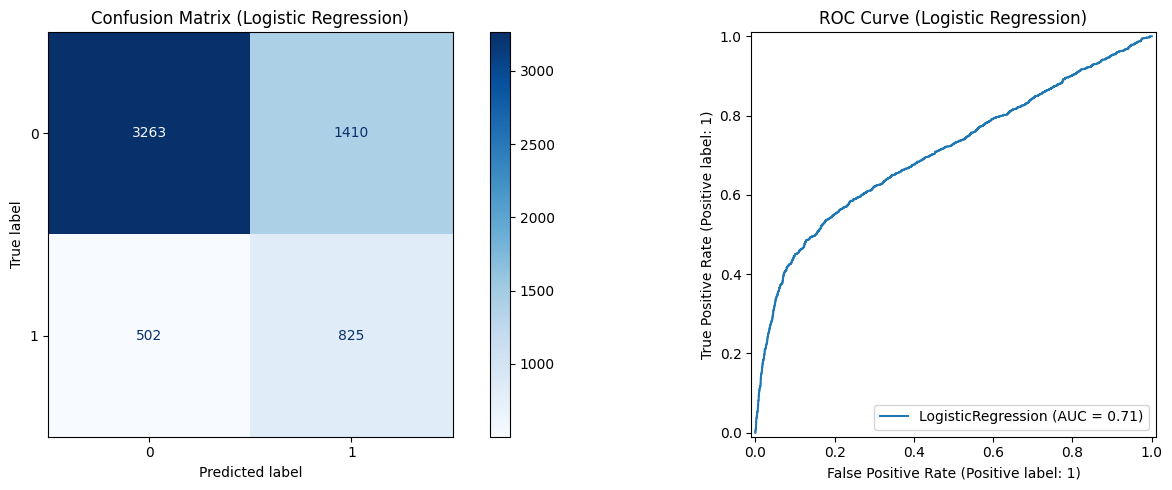

In [31]:
# Visualization of Confusion Matrix and ROC Curve
fig, ax = plt.subplots(1, 2, figsize=(15,5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[0], cmap='Blues')
ax[0].set_title("Confusion Matrix (Logistic Regression)")
RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax[1])
ax[1].set_title("ROC Curve (Logistic Regression)")
plt.tight_layout()
plt.show()

In [32]:
# Train Random Forest model 
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

# 7. Evaluate model
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Random Forest Report:\n")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

Random Forest Report:

              precision    recall  f1-score   support

           0       0.83      0.95      0.89      4673
           1       0.65      0.33      0.44      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.64      0.66      6000
weighted avg       0.79      0.81      0.79      6000

ROC-AUC Score: 0.7653


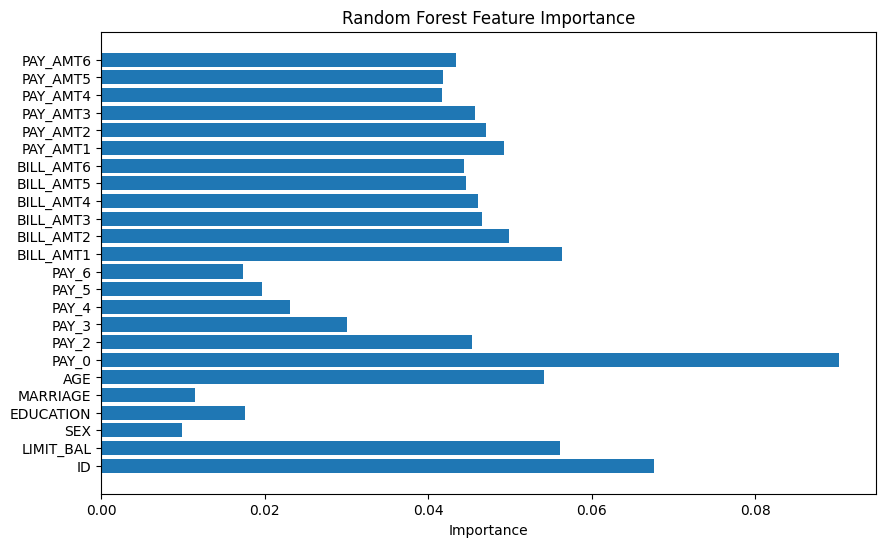

In [33]:
plt.figure(figsize=(10,6))
plt.barh(X.columns, model.feature_importances_)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

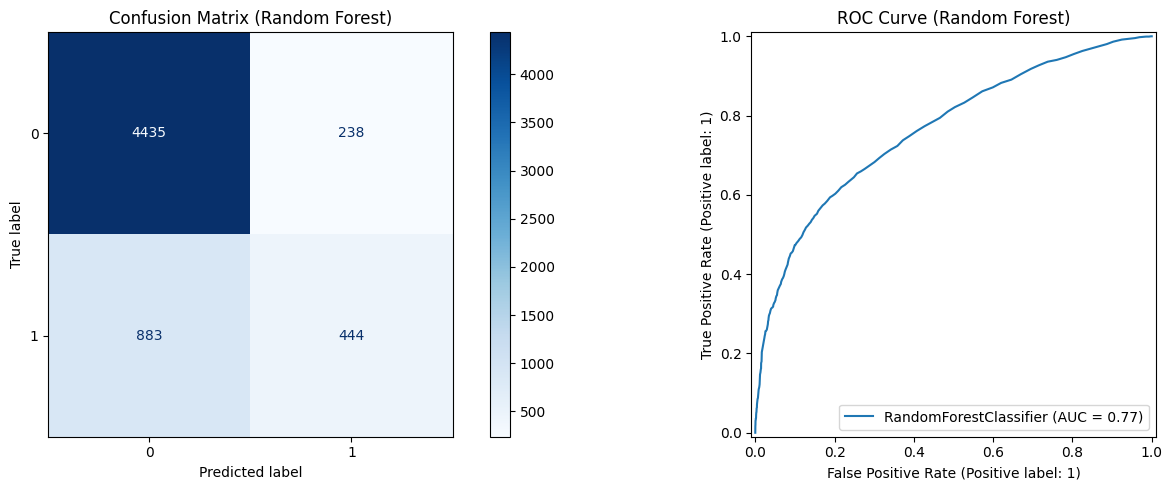

In [34]:
# Visualization of Confusion Matrix and ROC Curve
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[0], cmap='Blues')
ax[0].set_title("Confusion Matrix (Random Forest)")

# ROC Curve
RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax[1])
ax[1].set_title("ROC Curve (Random Forest)")

plt.tight_layout()
plt.show()

In [35]:
model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced",
    max_depth=5 
)

model.fit(X_train, y_train)

# 7. Evaluate model
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Decision Tree Report:\n")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

Decision Tree Report:

              precision    recall  f1-score   support

           0       0.87      0.83      0.85      4673
           1       0.48      0.55      0.52      1327

    accuracy                           0.77      6000
   macro avg       0.68      0.69      0.68      6000
weighted avg       0.78      0.77      0.78      6000

ROC-AUC Score: 0.7571


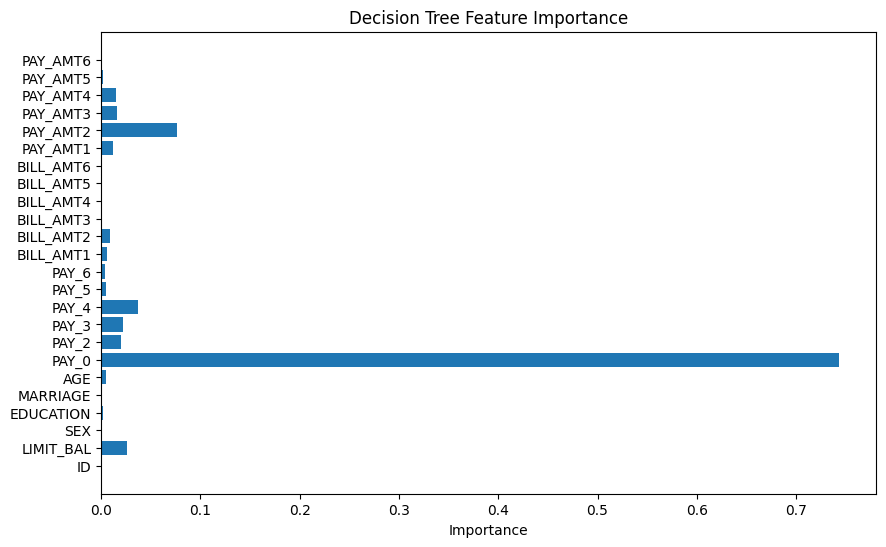

In [36]:
plt.figure(figsize=(10,6))
plt.barh(X.columns, model.feature_importances_)
plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.show()

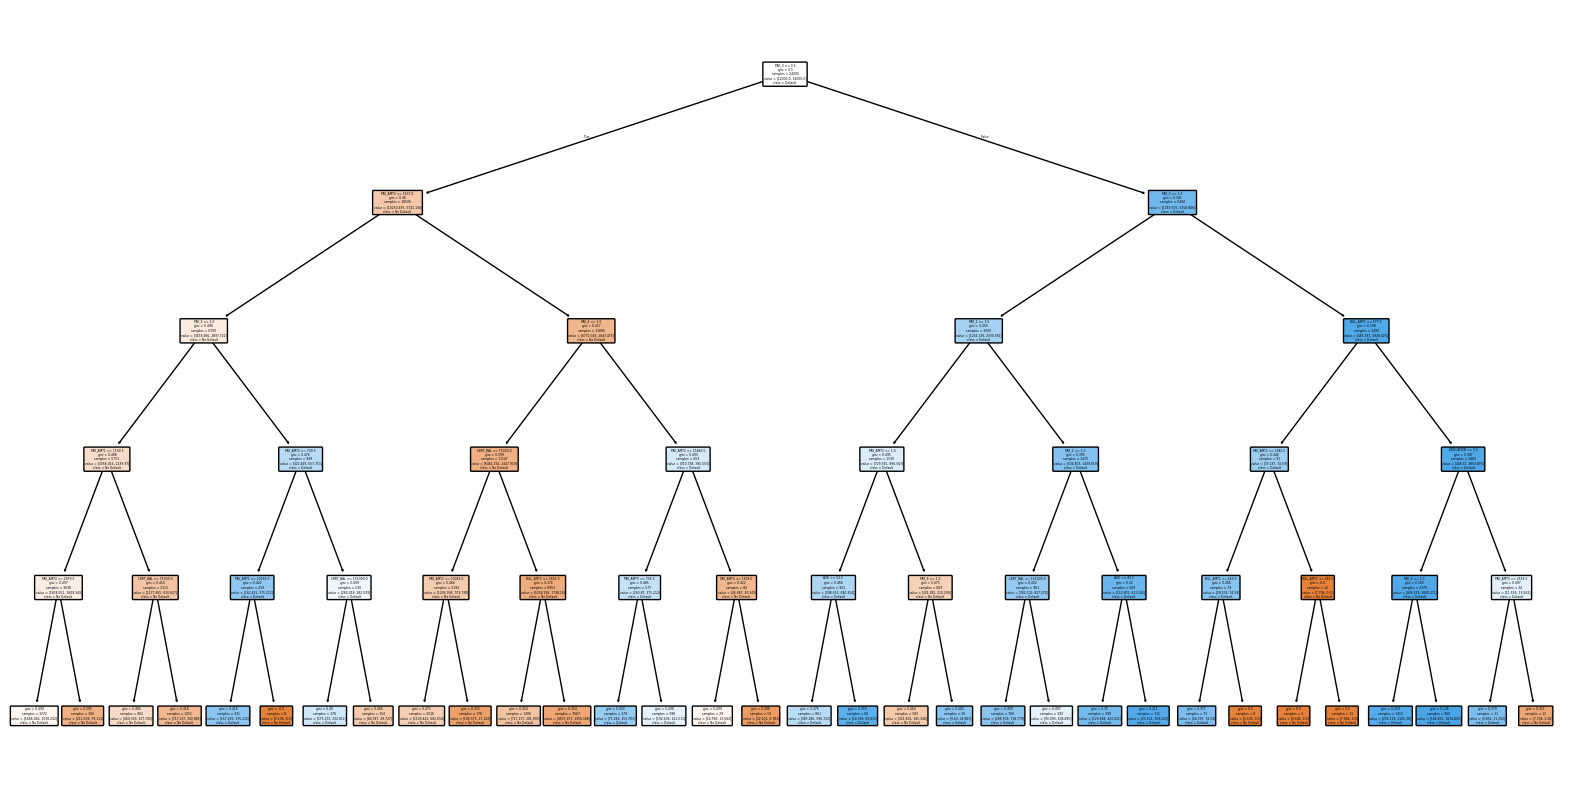

In [38]:
plt.figure(figsize=(20,10))
plot_tree(model, feature_names=X.columns, class_names=["No Default","Default"], filled=True, rounded=True)
plt.show()

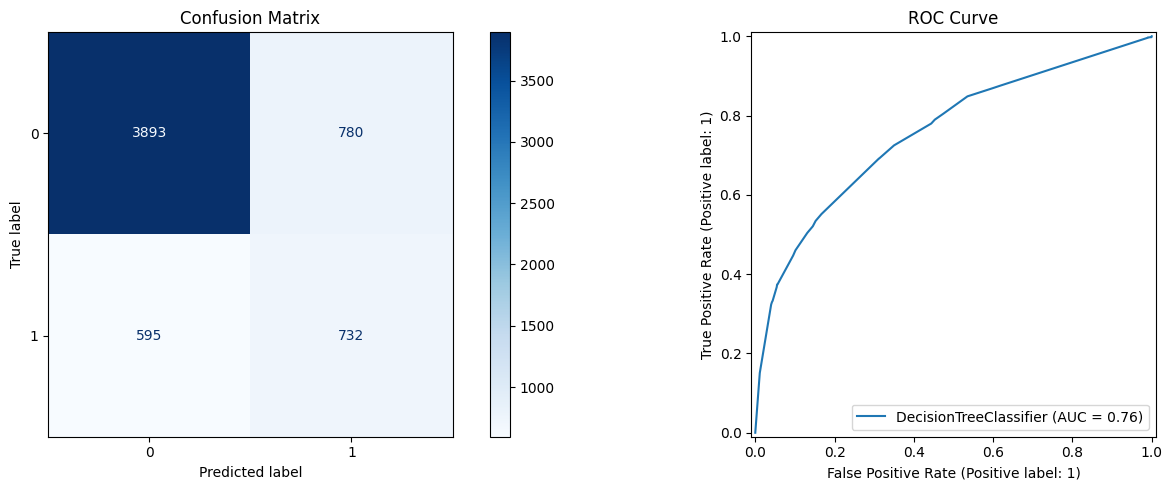

In [ ]:
# Visualization of Confusion Matrix and ROC Curve
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[0], cmap='Blues')
ax[0].set_title("Confusion Matrix (Decision Tree)")

# ROC Curve
RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax[1])
ax[1].set_title("ROC Curve (Decision Tree)")

plt.tight_layout()
plt.show()